<a href="https://colab.research.google.com/github/lkaba-pro/unsupervised-learning-clustering/blob/main/K_means_and_DBSCAN_clustering_on_FIFA_players_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stefanoleone992/fifa-22-complete-player-dataset")

print("Path to dataset files:", path)

100%|██████████| 109M/109M [00:00<00:00, 122MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/stefanoleone992/fifa-22-complete-player-dataset/versions/3


In [ ]:
players = pd.read_csv("/root/.cache/kagglehub/datasets/stefanoleone992/fifa-22-complete-player-dataset/versions/3/players_22.csv")

<ipython-input-6-f477b77735f6>:1: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  players = pd.read_csv("/root/.cache/kagglehub/datasets/stefanoleone992/fifa-22-complete-player-dataset/versions/3/players_22.csv")


In [ ]:
players.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [ ]:
features = ["overall", "potential", "wage_eur", "value_eur", "age"]

In [ ]:
players = players.dropna(subset=features)

In [ ]:
data = players[features].copy()

In [ ]:
data

,overall,potential,wage_eur,value_eur,age
0,93,93,320000.0,78000000.0,34
1,92,92,270000.0,119500000.0,32
2,91,91,270000.0,45000000.0,36
3,91,91,270000.0,129000000.0,29
4,91,91,350000.0,125500000.0,30
...,...,...,...,...,...
19234,47,52,1000.0,70000.0,22
19235,47,59,500.0,110000.0,19
19236,47,55,500.0,100000.0,21
19237,47,60,500.0,110000.0,19


# Pseudocode

## High level

1. Scale data to standardize values
2. Initialize random centroids
3. Get labels for each data point
4. Create new centroids
5. Plot the centroids
6. Repeat 3-5 until the centroids stop changing

In [ ]:
data = ((data - data.min()) / (data.max() - data.min())) * 10 + 1

In [ ]:
data.describe()

,overall,potential,wage_eur,value_eur,age
count,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000
mean,5.078302,5.799998,1.243826,1.146473,4.403716
std,1.496262,1.323418,0.557253,0.392477,1.750932
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.043478,4.913043,1.014306,1.024022,2.851852
50%,5.130435,5.782609,1.071531,1.049796,4.333333
75%,6.000000,6.652174,1.214592,1.102634,5.814815
max,11.000000,11.000000,11.000000,11.000000,11.000000


In [ ]:
data.head()

,overall,potential,wage_eur,value_eur,age
0,11.000000,10.565217,10.141631,5.020341,7.666667
1,10.782609,10.347826,8.711016,7.159616,6.925926
2,10.565217,10.130435,8.711016,3.319231,8.407407
3,10.565217,10.130435,8.711016,7.649329,5.814815
4,10.565217,10.130435,11.000000,7.468908,6.185185


In [ ]:
def random_centroids(data, k):
    centroids = []
    for i in range(k):
        centroid = data.apply(lambda x: float(x.sample()))
        centroids.append(centroid)
    return pd.concat(centroids, axis=1)

In [ ]:
centroids = random_centroids(data, 5)

<ipython-input-15-3d018814f2ee>:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  centroid = data.apply(lambda x: float(x.sample()))


In [ ]:
centroids

,0,1,2,3,4
overall,4.478261,4.260870,4.260870,3.608696,6.434783
potential,4.043478,7.304348,4.260870,4.913043,3.608696
wage_eur,1.128755,1.000000,1.042918,1.329041,1.002861
value_eur,1.118098,1.022733,1.016289,1.236660,1.360378
age,6.185185,4.333333,5.814815,6.555556,7.666667


In [ ]:
def get_labels(data, centroids):
    distances = centroids.apply(lambda x: np.sqrt(((data - x) ** 2).sum(axis=1)))
    return distances.idxmin(axis=1)

In [ ]:
labels = get_labels(data, centroids)

In [ ]:
labels.value_counts()

,count
1,10552
2,4887
0,1976
4,1738
3,12


In [ ]:
def new_centroids(data, labels, k):
    centroids = data.groupby(labels).apply(lambda x: np.exp(np.log(x).mean())).T
    return centroids

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [ ]:
def plot_clusters(data, labels, centroids, iteration):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centroids_2d = pca.transform(centroids.T)
    clear_output(wait=True)
    plt.title(f'Iteration {iteration}')
    plt.scatter(x=data_2d[:,0], y=data_2d[:,1], c=labels)
    plt.scatter(x=centroids_2d[:,0], y=centroids_2d[:,1])
    plt.show()

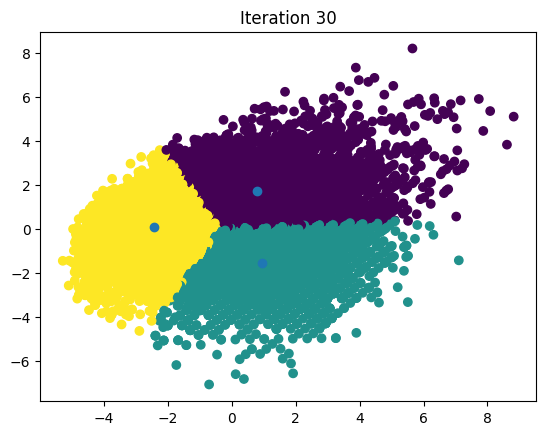

In [ ]:
max_iterations = 100
centroid_count = 3

centroids = random_centroids(data, centroid_count)
old_centroids = pd.DataFrame()
iteration = 1

while iteration < max_iterations and not centroids.equals(old_centroids):
    old_centroids = centroids

    labels = get_labels(data, centroids)
    centroids = new_centroids(data, labels, centroid_count)
    plot_clusters(data, labels, centroids, iteration)
    iteration += 1

In [ ]:
centroids

,0,1,2
overall,6.324628,5.200636,3.436536
potential,7.100439,4.894208,5.357557
wage_eur,1.456630,1.130961,1.031374
value_eur,1.311183,1.049892,1.029343
age,3.874397,5.963956,2.674807


In [ ]:
labels.value_counts()

,count
1,7188
2,6162
0,5815


In [ ]:
players[labels == 0][["short_name"] + features]

,short_name,overall,potential,wage_eur,value_eur,age
0,L. Messi,93,93,320000.0,78000000.0,34
1,R. Lewandowski,92,92,270000.0,119500000.0,32
2,Cristiano Ronaldo,91,91,270000.0,45000000.0,36
3,Neymar Jr,91,91,270000.0,129000000.0,29
4,K. De Bruyne,91,91,350000.0,125500000.0,30
...,...,...,...,...,...,...
13267,K. Nagera,63,80,8000.0,1300000.0,19
13351,Llabrés,63,81,3000.0,1200000.0,19
14026,M. Azeez,62,83,4000.0,1300000.0,18
14144,H. Mejbri,62,84,6000.0,1300000.0,18


In [ ]:
features

['overall', 'potential', 'wage_eur', 'value_eur', 'age']

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(3)
kmeans.fit(data)

KMeans(n_clusters=3)

In [ ]:
pd.DataFrame(kmeans.cluster_centers_, columns=features)

,overall,potential,wage_eur,value_eur,age
0,5.224513,4.892635,1.125683,1.044450,6.127575
1,3.895657,5.674066,1.044629,1.039951,2.908232
2,6.818005,7.250922,1.732639,1.461141,4.493127


In [ ]:
kmeans.cluster_centers_

array([[5.22451269, 4.89263504, 1.12568318, 1.04445018, 6.12757453],
       [3.89565661, 5.67406561, 1.04462928, 1.03995134, 2.90823208],
       [6.81800475, 7.25092154, 1.73263908, 1.46114101, 4.49312679]])

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
db = DBSCAN(eps=0.4, min_samples=15)
clusters = db.fit_predict(data)

In [ ]:
clusters, data[clusters == 0]

(array([-1, -1, -1, ..., -1, -1, -1]),
        overall  potential  wage_eur  value_eur       age  cluster
 1154  7.304348   6.869565  1.557940   1.257280  6.925926        0
 1165  7.304348   6.869565  1.500715   1.308829  6.925926        0
 1172  7.304348   6.869565  1.557940   1.308829  6.925926        0
 1183  7.304348   6.869565  1.300429   1.252125  6.925926        0
 1193  7.304348   6.869565  1.586552   1.257280  6.925926        0
 1201  7.304348   6.869565  1.329041   1.308829  6.925926        0
 1217  7.304348   6.869565  1.443491   1.257280  6.925926        0
 1234  7.304348   6.869565  1.329041   1.308829  6.925926        0
 1239  7.304348   6.869565  1.529328   1.308829  6.925926        0
 1270  7.304348   6.869565  1.472103   1.257280  6.925926        0
 1297  7.304348   6.869565  1.472103   1.308829  6.925926        0
 1301  7.304348   6.869565  1.329041   1.257280  6.925926        0)

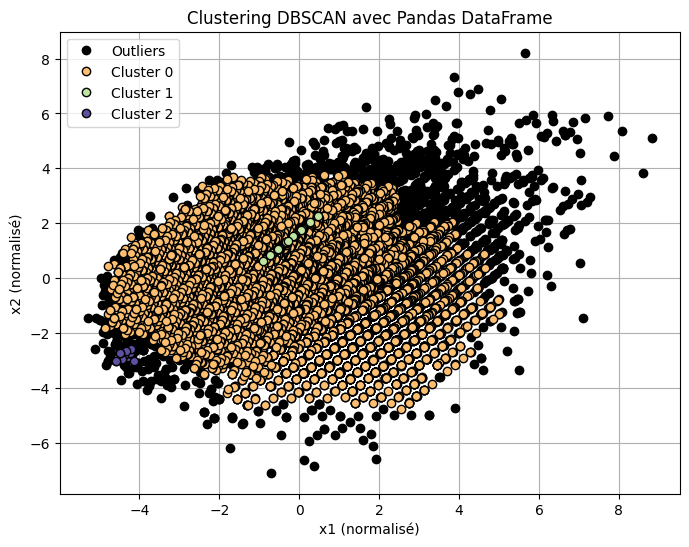

In [ ]:
# 5. Visualisation
plt.figure(figsize=(8, 6))
unique_labels = sorted(np.unique(clusters))
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)

data_2d= pd.DataFrame(data_2d)
data_2d['cluster']=clusters

nans=data['cluster'][data['cluster'].isna() == True]
for i in nans.index:
  data_2d['cluster']=clusters[i-74]

for label, col in zip(unique_labels, colors):
    if label == -1:
        col = [0, 0, 0, 1]  # noir pour le bruit
        label_name = "Outliers"
    else:
        label_name = f"Cluster {label}"


    cluster_data = data_2d[data_2d['cluster'] == label]
    plt.plot(cluster_data[0], cluster_data[1], 'o',
             markerfacecolor=tuple(col), markeredgecolor='k',
             markersize=6, label=label_name)

plt.title("Clustering DBSCAN avec Pandas DataFrame")
plt.xlabel("x1 (normalisé)")
plt.ylabel("x2 (normalisé)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
players.iloc[data_2d[data_2d['cluster']== 1].index][['short_name'] + features]

,short_name,overall,potential,wage_eur,value_eur,age
1825,Juli Freitinho,75,75,9000.0,6000000.0,21
1835,Davi Parrela,75,75,9000.0,6000000.0,21
1841,Rafael Cachoira,75,75,11000.0,6000000.0,21
2248,Caio Nunson,74,74,9000.0,4400000.0,21
2258,Victorino Magela,74,74,6000.0,3700000.0,21
2268,Edercinho Sepa,74,74,16000.0,4400000.0,21
2866,Osvaldão Murilo,73,73,9000.0,3100000.0,21
2871,Nicolás Formido,73,73,16000.0,3600000.0,21
2877,Neviano Neves,73,73,17000.0,3600000.0,21
2884,Luis Couprins,73,73,9000.0,3200000.0,21
